# XGBoost metadata model

Binary classification using patient metadata.

Current hypothesis:
- H1: biopsy recommendation
- H2: malignancy among biopsied lesions

Model selection is performed exclusively on the training set using patient-grouped cross-validation.

## 1. Imports and configuration 

In [40]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------


import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedGroupKFold,
)

from sklearn.metrics import (
    auc,
    make_scorer,
    precision_recall_curve,
)

from xgboost import XGBClassifier

from skin_lesion_ai.inference.evaluation import (
    evaluate,
    save_model,
)
from skin_lesion_ai.utils.data_utils import load_metadata_parquet


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 2

RANDOM_STATE = 42
N_CV_SPLITS = 5

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_suffix": "h1",
        "description": "Biopsy recommendation",
    },
    2: {
        "target": "target_malignant",
        "split_suffix": "h2",
        "description": "Malignancy among biopsied lesions",
    },
}

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_SUFFIX = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_suffix"]
HYPOTHESIS_DESCRIPTION = HYPOTHESIS_CONFIG[HYPOTHESIS]["description"]

MODEL_NAME = f"xgboost_metadata_h{HYPOTHESIS}"

print(f"Hypothesis {HYPOTHESIS}: {HYPOTHESIS_DESCRIPTION}")
print(f"Target: {TARGET}")
print(f"Model name: {MODEL_NAME}")

Hypothesis 2: Malignancy among biopsied lesions
Target: target_malignant
Model name: xgboost_metadata_h2


## 2. Load train, validation and test splits 

In [41]:
df_train = load_metadata_parquet(
    stage="processed",
    filename=f"train_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_validation = load_metadata_parquet(
    stage="processed",
    filename=f"val_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_test = load_metadata_parquet(
    stage="processed",
    filename=f"test_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)


split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "lesions": [
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "patients": [
            df_train["patient_id"].nunique(),
            df_validation["patient_id"].nunique(),
            df_test["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train[TARGET].mean(),
            df_validation[TARGET].mean(),
            df_test[TARGET].mean(),
        ],
    }
)

display(split_summary)

,split,lesions,patients,positive_rate
0,train,811,504,0.374846
1,validation,101,64,0.376238
2,test,101,61,0.376238


## 3. Define predictors and target

The model uses four clinical metadata predictors:

- sex
- age
- anatomical site
- lesion diameter

Categorical variables use the encodings generated during preprocessing.
Anatomical site is represented through one-hot encoded columns rather than the integer code, avoiding the introduction of an artificial ordinal relationship.

In [42]:
FEATURES = [
    "sex_male",
    "age_approx",
    "anatom_site__anterior_torso",
    "anatom_site__head_neck",
    "anatom_site__lower_extremity",
    "anatom_site__posterior_torso",
    "anatom_site__upper_extremity",
    "clin_size_long_diam_mm",
]

ID_COLUMN = "isic_id"
GROUP_COLUMN = "patient_id"


required_columns = {
    ID_COLUMN,
    GROUP_COLUMN,
    TARGET,
    *FEATURES,
}

for split_name, df_split in {
    "train": df_train,
    "validation": df_validation,
    "test": df_test,
}.items():
    missing_columns = required_columns.difference(df_split.columns)

    if missing_columns:
        raise KeyError(
            f"{split_name} is missing required columns: {sorted(missing_columns)}"
        )

    if df_split[FEATURES].isna().any().any():
        raise ValueError(f"Missing predictor values found in {split_name}.")

print(f"Number of model columns: {len(FEATURES)}")
print("Predictors:")
for feature in FEATURES:
    print(f"- {feature}")

Number of model columns: 8
Predictors:
- sex_male
- age_approx
- anatom_site__anterior_torso
- anatom_site__head_neck
- anatom_site__lower_extremity
- anatom_site__posterior_torso
- anatom_site__upper_extremity
- clin_size_long_diam_mm


## 4. Prepare modelling matrices

Predictor matrices and target vectors are created for each split.

Patient identifiers are additionally retained as grouping labels for the cross-validation procedure. This allows `StratifiedGroupKFold` to preserve patient independence within the training set and prevents lesions from the same
patient from appearing in both training and validation folds.

In [43]:
# Training data
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].astype(int).copy()
groups_train = df_train[GROUP_COLUMN].copy()

# Validation data
X_validation = df_validation[FEATURES].copy()
y_validation = df_validation[TARGET].astype(int).copy()

# Test data
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].astype(int).copy()


print("Training:")
print(f"  X: {X_train.shape}")
print(f"  y: {y_train.shape}")
print(f"  patients: {groups_train.nunique():,}")

print("\nValidation:")
print(f"  X: {X_validation.shape}")
print(f"  y: {y_validation.shape}")

print("\nTest:")
print(f"  X: {X_test.shape}")
print(f"  y: {y_test.shape}")

Training:
  X: (811, 8)
  y: (811,)
  patients: 504

Validation:
  X: (101, 8)
  y: (101,)

Test:
  X: (101, 8)
  y: (101,)


## 5. Cross-validation and scoring strategy

Hyperparameter optimization is performed exclusively within the training set.

Because multiple lesions may belong to the same patient, standard stratified cross-validation would introduce patient-level leakage between folds.
Therefore, a `StratifiedGroupKFold` strategy is used, preserving class balance as far as possible while ensuring that all lesions from the same patient remain within the same fold.

The same five folds are precomputed and reused throughout all hyperparameter search stages to ensure a fair comparison between candidate models.

Candidate models are evaluated using three threshold-independent metrics:

1. **PR-AUC**, used as the primary selection criterion because of the strong class imbalance.
2. **ROC-AUC**, used as the first tie-breaker.
3. **Brier score**, used as the second tie-breaker to favor better-calibrated probability estimates.

PR-AUC is computed as the trapezoidal area under the Precision-Recall curve, using the same definition as the final evaluation pipeline.

No classification threshold is selected during cross-validation. Clinical threshold selection is performed later and exclusively on the validation set.

In [44]:
# ---------------------------------------------------------------------
# Cross-validation
# ---------------------------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Precompute folds so that exactly the same splits are reused during all hyperparameter search stages.
cv_splits = list(
    cv.split(
        X=X_train,
        y=y_train,
        groups=groups_train,
    )
)


# ---------------------------------------------------------------------
# Validate CV folds
# ---------------------------------------------------------------------

cv_summary = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    train_patients = set(groups_train.iloc[train_idx])
    val_patients = set(groups_train.iloc[val_idx])

    if train_patients.intersection(val_patients):
        raise ValueError(f"Patient leakage detected in CV fold {fold}.")

    cv_summary.append(
        {
            "fold": fold,
            "train_lesions": len(train_idx),
            "validation_lesions": len(val_idx),
            "train_patients": len(train_patients),
            "validation_patients": len(val_patients),
            "train_positive_rate": y_train.iloc[train_idx].mean(),
            "validation_positive_rate": y_train.iloc[val_idx].mean(),
        }
    )

cv_summary = pd.DataFrame(cv_summary)

display(cv_summary)

,fold,train_lesions,validation_lesions,train_patients,validation_patients,train_positive_rate,validation_positive_rate
0,1,649,162,400,104,0.374422,0.376543
1,2,649,162,401,103,0.374422,0.376543
2,3,649,162,402,102,0.375963,0.370370
3,4,649,162,409,95,0.374422,0.376543
4,5,648,163,404,100,0.375000,0.374233


In [45]:
# ---------------------------------------------------------------------
# Scoring functions
# ---------------------------------------------------------------------


def trapezoidal_pr_auc(y_true, y_prob):
    """Compute trapezoidal area under the Precision-Recall curve."""
    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob,
    )

    return auc(recall, precision)


pr_auc_scorer = make_scorer(
    trapezoidal_pr_auc,
    response_method="predict_proba",
)


SCORING = {
    "pr_auc": pr_auc_scorer,
    "roc_auc": "roc_auc",
    "brier": "neg_brier_score",
}


def select_best_candidate(cv_results):
    """Select the best candidate using PR-AUC > ROC-AUC > Brier score."""

    results = pd.DataFrame(cv_results)

    ranked_results = results.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        na_position="last",
    )

    return int(ranked_results.index[0])

## 6. Broad hyperparameter search

A broad randomized search is first performed to explore the main dimensions controlling XGBoost learning, model complexity, regularization and class imbalance.

A randomized search is preferred over a fully exhaustive grid at this stage.

The search explores:

- number of boosting trees and learning rate;
- tree depth and minimum child weight;
- row and feature subsampling;
- minimum split loss (`gamma`);
- L1 and L2 regularization;
- positive-class weighting.

The best region identified in this stage is subsequently explored using a smaller exhaustive grid.

In [46]:
# ---------------------------------------------------------------------
# Class imbalance
# ---------------------------------------------------------------------

n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())

class_ratio = n_negative / n_positive

scale_pos_weight_values = sorted(
    {
        1.0,
        round(np.sqrt(class_ratio), 4),
        round(class_ratio, 4),
    }
)

print(f"Negative lesions: {n_negative:,}")
print(f"Positive lesions: {n_positive:,}")
print(f"Negative / positive ratio: {class_ratio:.3f}")
print(f"scale_pos_weight candidates: {scale_pos_weight_values}")

Negative lesions: 507
Positive lesions: 304
Negative / positive ratio: 1.668
scale_pos_weight candidates: [1.0, np.float64(1.2914), 1.6678]


`scale_pos_weight` controls the relative contribution of positive-class observations to the XGBoost loss function. 

A value of 1 applies no class weighting, whereas larger values increase the penalty associated with errors on positive observations.

Three values are explored: no weighting (`1`), an intermediate correction (`sqrt(n_negative / n_positive)`), and the full negative-to-positive class
ratio (`n_negative / n_positive`). 

This allows cross-validation to determine whether explicit class-imbalance compensation improves model performance.

In [47]:
# ---------------------------------------------------------------------
# Base XGBoost classifier
# ---------------------------------------------------------------------

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)


# ---------------------------------------------------------------------
# Broad search space
# ---------------------------------------------------------------------

broad_param_space = {
    "n_estimators": [
        200,
        400,
        600,
        800,
        1000,
        1400,
    ],
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10,
        0.20,
    ],
    "max_depth": [
        2,
        3,
        4,
        5,
        6,
    ],
    "min_child_weight": [
        1,
        3,
        5,
        10,
        20,
    ],
    "subsample": [
        0.6,
        0.8,
        1.0,
    ],
    "colsample_bytree": [
        0.6,
        0.8,
        1.0,
    ],
    "gamma": [
        0.0,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
    ],
    "reg_alpha": [
        0.0,
        0.01,
        0.1,
        1.0,
        5.0,
    ],
    "reg_lambda": [
        0.5,
        1.0,
        2.0,
        5.0,
        10.0,
    ],
    "scale_pos_weight": scale_pos_weight_values,
}

In [48]:
# ---------------------------------------------------------------------
# Broad randomized search
# ---------------------------------------------------------------------

N_RANDOM_ITER = 150

broad_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=broad_param_space,
    n_iter=N_RANDOM_ITER,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

broad_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=1.6678, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=1.6678, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=1.6678, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=1.6678, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=1.0, gamma=2.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=800, reg_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...t 0x166ce5760>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother 

## 7. Refined hyperparameter search

The best configuration from the broad randomized search is used to define a smaller local search space.

The refined search focuses on the parameters most directly controlling boosting capacity and class weighting:

- `n_estimators`;
- `learning_rate`;
- `max_depth`;
- `min_child_weight`;
- `scale_pos_weight`.

Sampling and regularization parameters are fixed at their best values from the broad search.

The broad-search optimum is explicitly included in the refined grid.

In [49]:
# ---------------------------------------------------------------------
# Best broad-search configuration
# ---------------------------------------------------------------------

broad_best_params = broad_search.best_params_

broad_results = pd.DataFrame(broad_search.cv_results_)
broad_best_row = broad_results.loc[broad_search.best_index_]

print("Broad search best CV performance:")
print(
    f"PR-AUC: "
    f"{broad_best_row['mean_test_pr_auc']:.5f} "
    f"± {broad_best_row['std_test_pr_auc']:.5f}"
)
print(
    f"ROC-AUC: "
    f"{broad_best_row['mean_test_roc_auc']:.5f} "
    f"± {broad_best_row['std_test_roc_auc']:.5f}"
)
print(f"Brier score: {-broad_best_row['mean_test_brier']:.5f}")

print("\nBest broad-search parameters:")
display(broad_best_params)

Broad search best CV performance:
PR-AUC: 0.62797 ± 0.07440
ROC-AUC: 0.75255 ± 0.04029
Brier score: 0.19625

Best broad-search parameters:


{'subsample': 1.0,
 'scale_pos_weight': 1.0,
 'reg_lambda': 1.0,
 'reg_alpha': 0.1,
 'n_estimators': 1000,
 'min_child_weight': 3,
 'max_depth': 2,
 'learning_rate': 0.01,
 'gamma': 1.0,
 'colsample_bytree': 0.8}

In [50]:
# ---------------------------------------------------------------------
# Build refined grid around broad-search optimum
# ---------------------------------------------------------------------

best_n_estimators = broad_best_params["n_estimators"]
best_learning_rate = broad_best_params["learning_rate"]
best_max_depth = broad_best_params["max_depth"]
best_min_child_weight = broad_best_params["min_child_weight"]
best_scale_pos_weight = broad_best_params["scale_pos_weight"]


refined_param_grid = {
    "n_estimators": sorted(
        {
            max(100, int(round(best_n_estimators * 0.75))),
            best_n_estimators,
            int(round(best_n_estimators * 1.25)),
        }
    ),
    "learning_rate": sorted(
        {
            max(0.005, best_learning_rate * 0.7),
            best_learning_rate,
            min(0.30, best_learning_rate * 1.3),
        }
    ),
    "max_depth": sorted(
        {
            max(1, best_max_depth - 1),
            best_max_depth,
            best_max_depth + 1,
        }
    ),
    "min_child_weight": sorted(
        {
            max(1, best_min_child_weight / 2),
            best_min_child_weight,
            best_min_child_weight * 2,
        }
    ),
    "scale_pos_weight": sorted(
        {
            max(0.1, best_scale_pos_weight * 0.75),
            best_scale_pos_weight,
            best_scale_pos_weight * 1.25,
        }
    ),
}

refined_param_grid

{'n_estimators': [750, 1000, 1250],
 'learning_rate': [0.006999999999999999, 0.01, 0.013000000000000001],
 'max_depth': [1, 2, 3],
 'min_child_weight': [1.5, 3, 6],
 'scale_pos_weight': [0.75, 1.0, 1.25]}

In [51]:
# ---------------------------------------------------------------------
# Fix broad-search sampling and regularization parameters
# ---------------------------------------------------------------------

refined_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
    subsample=broad_best_params["subsample"],
    colsample_bytree=broad_best_params["colsample_bytree"],
    gamma=broad_best_params["gamma"],
    reg_alpha=broad_best_params["reg_alpha"],
    reg_lambda=broad_best_params["reg_lambda"],
)

In [52]:
# ---------------------------------------------------------------------
# Refined exhaustive search
# ---------------------------------------------------------------------

refined_search = GridSearchCV(
    estimator=refined_xgb_model,
    param_grid=refined_param_grid,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    n_jobs=-1,
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

refined_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=0.75; total time=   0.4s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=0.75; total time=   0.4s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=0.75; total time=   0.4s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=0.75; total time=   0.3s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=1.0; total time=   0.2s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750, scale_pos_weight=0.75; total time=   0.2s
[CV] END learning_rate=0.006999999999999999, max_depth=1, min_child_weight=1.5, n_estimators=750,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.006999999999999999, 0.01, ...], 'max_depth': [1, 2, ...], 'min_child_weight': [1.5, 3, ...], 'n_estimators': [750, 1000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...t 0x166ce5760>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variou

## 8. Cross-validation results and final model

The best configurations from the broad and refined searches are compared using their mean cross-validated PR-AUC, ROC-AUC and Brier score.

The final configuration is selected using the predefined hierarchy:

**PR-AUC → ROC-AUC → Brier score.**

Because the refined `GridSearchCV` uses `refit`, the selected estimator is automatically retrained on the complete training set after hyperparameter selection. No additional manual fitting step is therefore required.

In [53]:
# ---------------------------------------------------------------------
# Collect CV results
# ---------------------------------------------------------------------

broad_cv_results = pd.DataFrame(broad_search.cv_results_)

refined_cv_results = pd.DataFrame(refined_search.cv_results_)


def get_best_search_result(search, search_name):
    """Return the selected CV result from one search stage."""

    results = pd.DataFrame(search.cv_results_)
    row = results.loc[search.best_index_]

    return {
        "search": search_name,
        "pr_auc": row["mean_test_pr_auc"],
        "pr_auc_std": row["std_test_pr_auc"],
        "roc_auc": row["mean_test_roc_auc"],
        "roc_auc_std": row["std_test_roc_auc"],
        "brier_score": -row["mean_test_brier"],
        "brier_score_std": row["std_test_brier"],
    }


search_comparison = pd.DataFrame(
    [
        get_best_search_result(
            broad_search,
            "Broad randomized search",
        ),
        get_best_search_result(
            refined_search,
            "Refined grid search",
        ),
    ]
)

display(search_comparison)

,search,pr_auc,pr_auc_std,roc_auc,roc_auc_std,brier_score,brier_score_std
0,Broad randomized search,0.627974,0.074400,0.752549,0.040290,0.196245,0.012291
1,Refined grid search,0.631885,0.086939,0.753357,0.047292,0.201105,0.014294


In [54]:
# ---------------------------------------------------------------------
# Top refined-search candidates
# ---------------------------------------------------------------------

top_refined_models = refined_cv_results.copy()

top_refined_models["mean_brier_score"] = -top_refined_models["mean_test_brier"]

top_refined_models = (
    top_refined_models.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )[
        [
            "params",
            "mean_test_pr_auc",
            "std_test_pr_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_brier_score",
            "std_test_brier",
            "mean_fit_time",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

display(top_refined_models)

,params,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,std_test_roc_auc,mean_brier_score,std_test_brier,mean_fit_time
0,"{'learning_rate': 0.006999999999999999, 'max_d...",0.631885,0.086939,0.753357,0.047292,0.201105,0.014294,0.648541
1,"{'learning_rate': 0.006999999999999999, 'max_d...",0.631835,0.086887,0.753292,0.047231,0.201086,0.014307,0.399563
2,"{'learning_rate': 0.01, 'max_depth': 1, 'min_c...",0.631643,0.084970,0.753098,0.044553,0.201025,0.014324,0.404922
3,"{'learning_rate': 0.01, 'max_depth': 1, 'min_c...",0.631643,0.084970,0.753098,0.044553,0.201025,0.014324,0.309742
4,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631591,0.085194,0.752904,0.044953,0.201064,0.014321,0.298579
5,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631591,0.085194,0.752904,0.044953,0.201064,0.014321,0.254997
6,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631591,0.085194,0.752904,0.044953,0.201065,0.014320,0.218103
7,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631541,0.085144,0.752839,0.044898,0.201025,0.014330,0.277835
8,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631541,0.085144,0.752839,0.044898,0.201025,0.014330,0.225617
9,"{'learning_rate': 0.013000000000000001, 'max_d...",0.631541,0.085144,0.752839,0.044898,0.201025,0.014330,0.170638


In [55]:
# ---------------------------------------------------------------------
# Final model
# ---------------------------------------------------------------------

best_model = refined_search.best_estimator_

final_model_params = {
    **broad_best_params,
    **refined_search.best_params_,
}

print("Final selected hyperparameters:")
display(final_model_params)

print(f"Final model automatically refitted on {len(X_train):,} training lesions.")

Final selected hyperparameters:


{'subsample': 1.0,
 'scale_pos_weight': 0.75,
 'reg_lambda': 1.0,
 'reg_alpha': 0.1,
 'n_estimators': 1250,
 'min_child_weight': 1.5,
 'max_depth': 1,
 'learning_rate': 0.006999999999999999,
 'gamma': 1.0,
 'colsample_bytree': 0.8}

Final model automatically refitted on 811 training lesions.


## 9. Save final model

The best model selected through cross-validation is saved before evaluating its performance on the validation set.

In [56]:
model_directory = save_model(
    model=best_model,
    model_name=MODEL_NAME,
    model_type=1,
)

print(f"Model directory: {model_directory}")

Model saved in: /Users/carlesraichbros/my-image-classifier/data/models/xgboost_metadata_h2/model.joblib
Model directory: /Users/carlesraichbros/my-image-classifier/data/models/xgboost_metadata_h2


## 10. Generate prediction probabilities

Positive-class probabilities are generated for the training and validation sets.

In [57]:
train_probabilities = best_model.predict_proba(X_train)[:, 1]

validation_probabilities = best_model.predict_proba(X_validation)[:, 1]


df_train_predictions = pd.DataFrame(
    {
        "isic_id": df_train["isic_id"].to_numpy(),
        "probability": train_probabilities,
    }
)

df_validation_predictions = pd.DataFrame(
    {
        "isic_id": df_validation["isic_id"].to_numpy(),
        "probability": validation_probabilities,
    }
)

display(df_train_predictions.head())
display(df_validation_predictions.head())

,isic_id,probability
0,ISIC_0077462,0.550150
1,ISIC_0079802,0.063923
2,ISIC_0082829,0.653187
3,ISIC_0085805,0.064367
4,ISIC_0096034,0.634015


,isic_id,probability
0,ISIC_0293670,0.456031
1,ISIC_0373748,0.245704
2,ISIC_0470650,0.138223
3,ISIC_0664135,0.655406
4,ISIC_0699524,0.336251


## 11. Train and validation evaluation

Threshold-independent discrimination and calibration metrics are calculated for both splits. 
The clinical classification threshold is selected exclusively from the validation set by maximizing specificity while maintaining the predefined minimum sensitivity.

The selected threshold is subsequently applied unchanged to both training and validation data.

In [58]:
results = evaluate(
    df_train_predictions=df_train_predictions,
    df_validation_predictions=df_validation_predictions,
    df_train=df_train,
    df_validation=df_validation,
    hypothesis=HYPOTHESIS,
    model_directory=model_directory,
    target_sensitivity=0.95,
)

display(results["summary"])

TRAIN AND VALIDATION EVALUATION
Model: xgboost_metadata_h2
Hypothesis 2: Lesion suspected to be malignant
------------------------------------------------------------------------
                                   Train      Validation
Lesions                              811             101
Patients                             504              64
Lesion prevalence                 0.3748          0.3762
------------------------------------------------------------------------
PR-AUC                            0.6680          0.5996
ROC-AUC                           0.7747          0.7412
Brier score                       0.1897          0.1937
------------------------------------------------------------------------
Selected validation threshold: 0.190596
Target sensitivity: 0.950
------------------------------------------------------------------------
Sensitivity                       0.9474          0.9737
Specificity                       0.3097          0.2857
PPV                    

,metric,train,validation
0,total_lesions,811.000000,101.000000
1,total_patients,504.000000,64.000000
2,positive_lesions,304.000000,38.000000
3,negative_lesions,507.000000,63.000000
4,patients_with_positive_lesion,201.000000,22.000000
5,lesion_prevalence,0.374846,0.376238
6,patient_prevalence,0.398810,0.343750
7,pr_auc,0.667962,0.599645
8,roc_auc,0.774658,0.741228
9,brier_score,0.189681,0.193679


### Precision Recall Curve

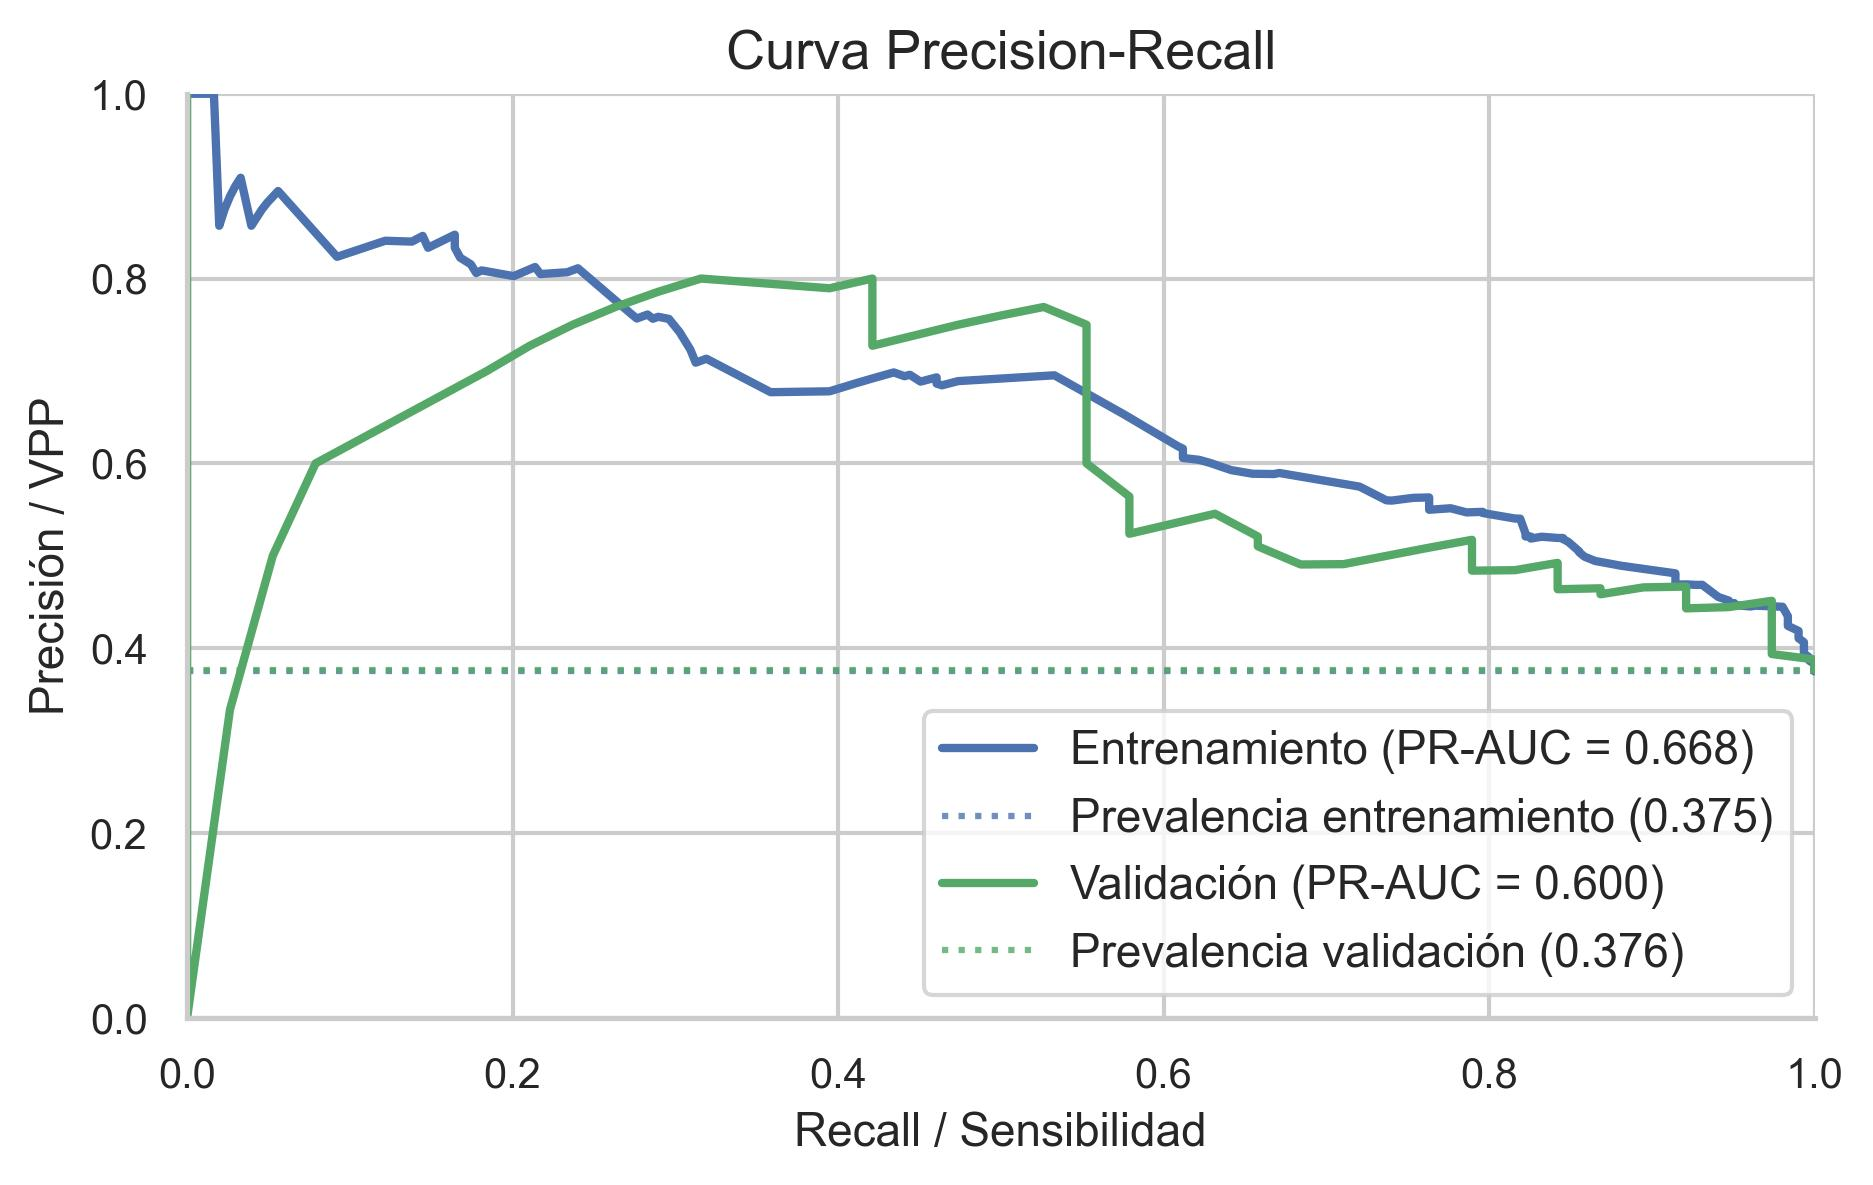

### Roc Curve

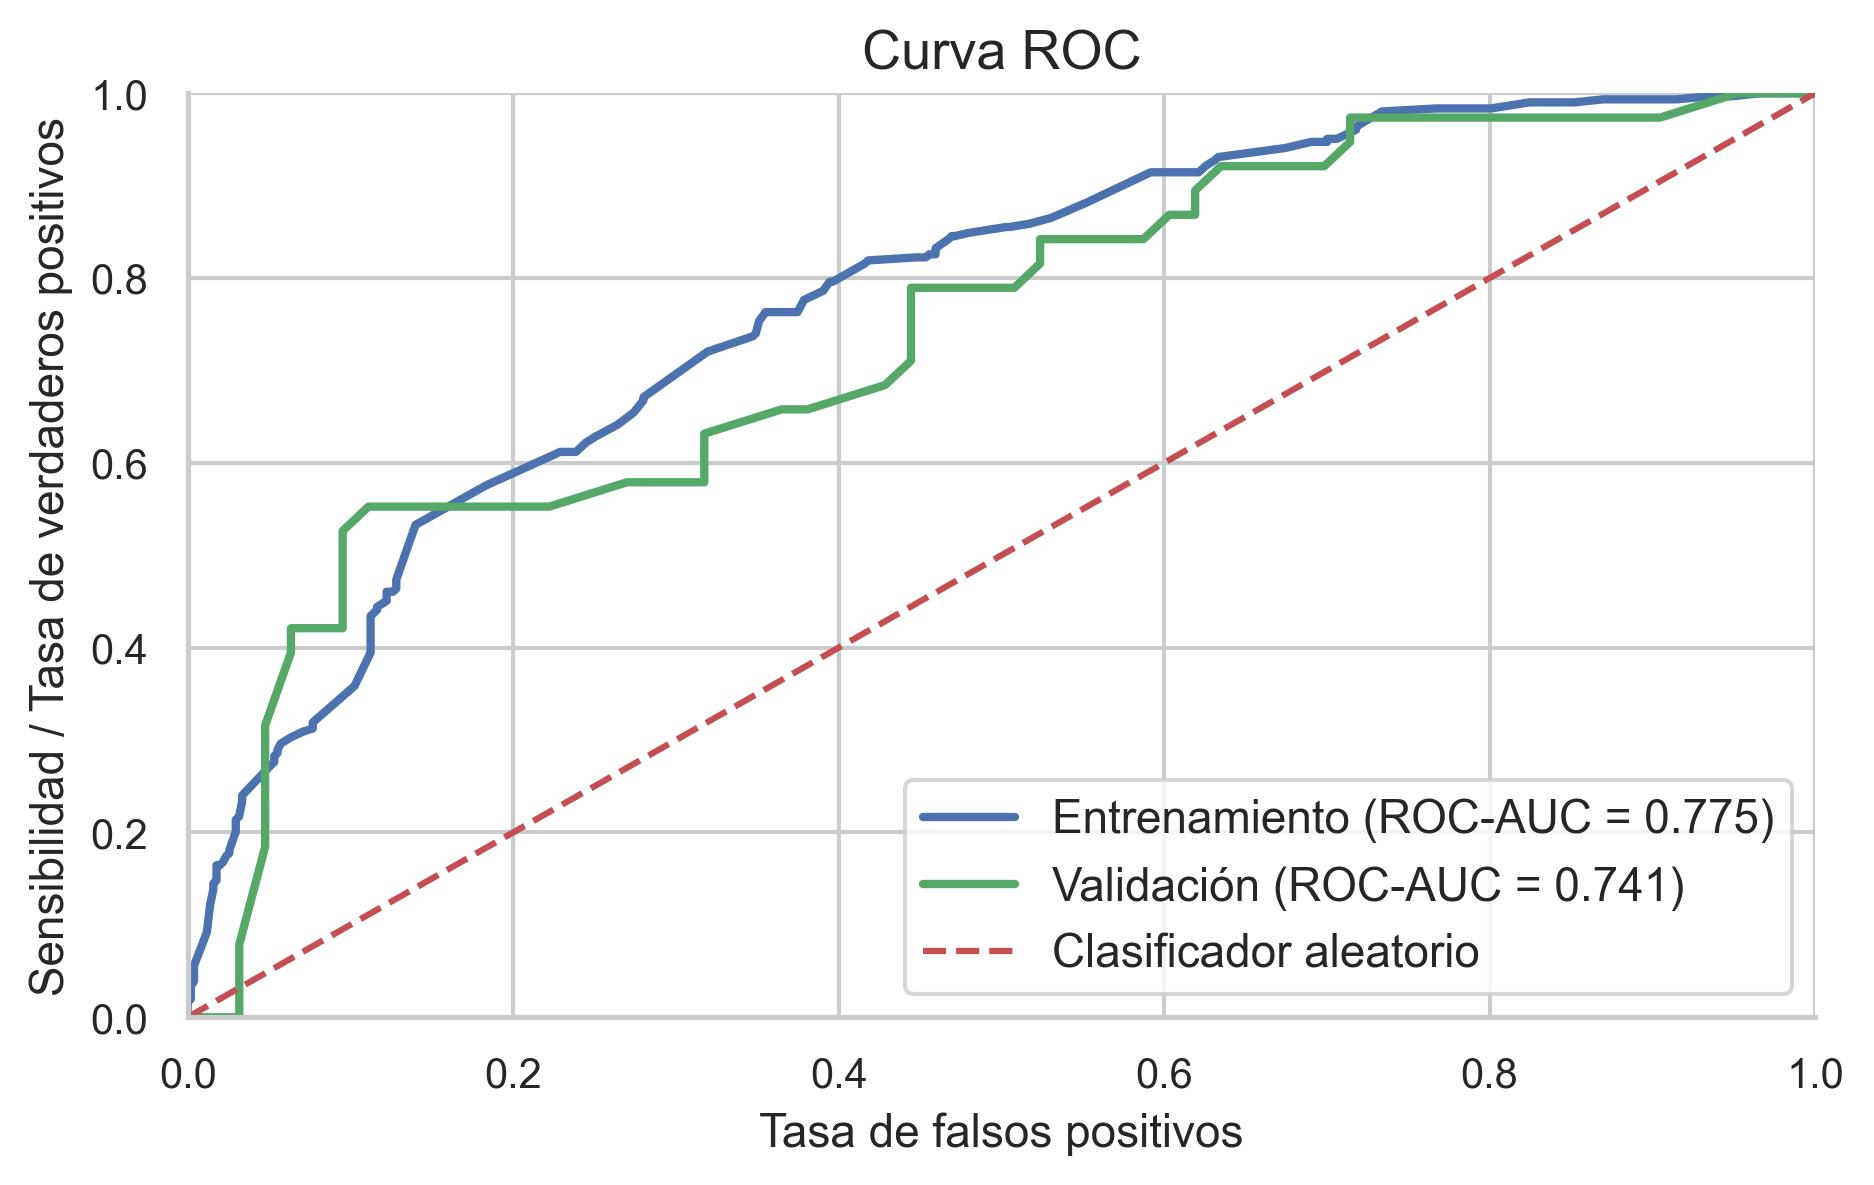

### Pr Roc Curves

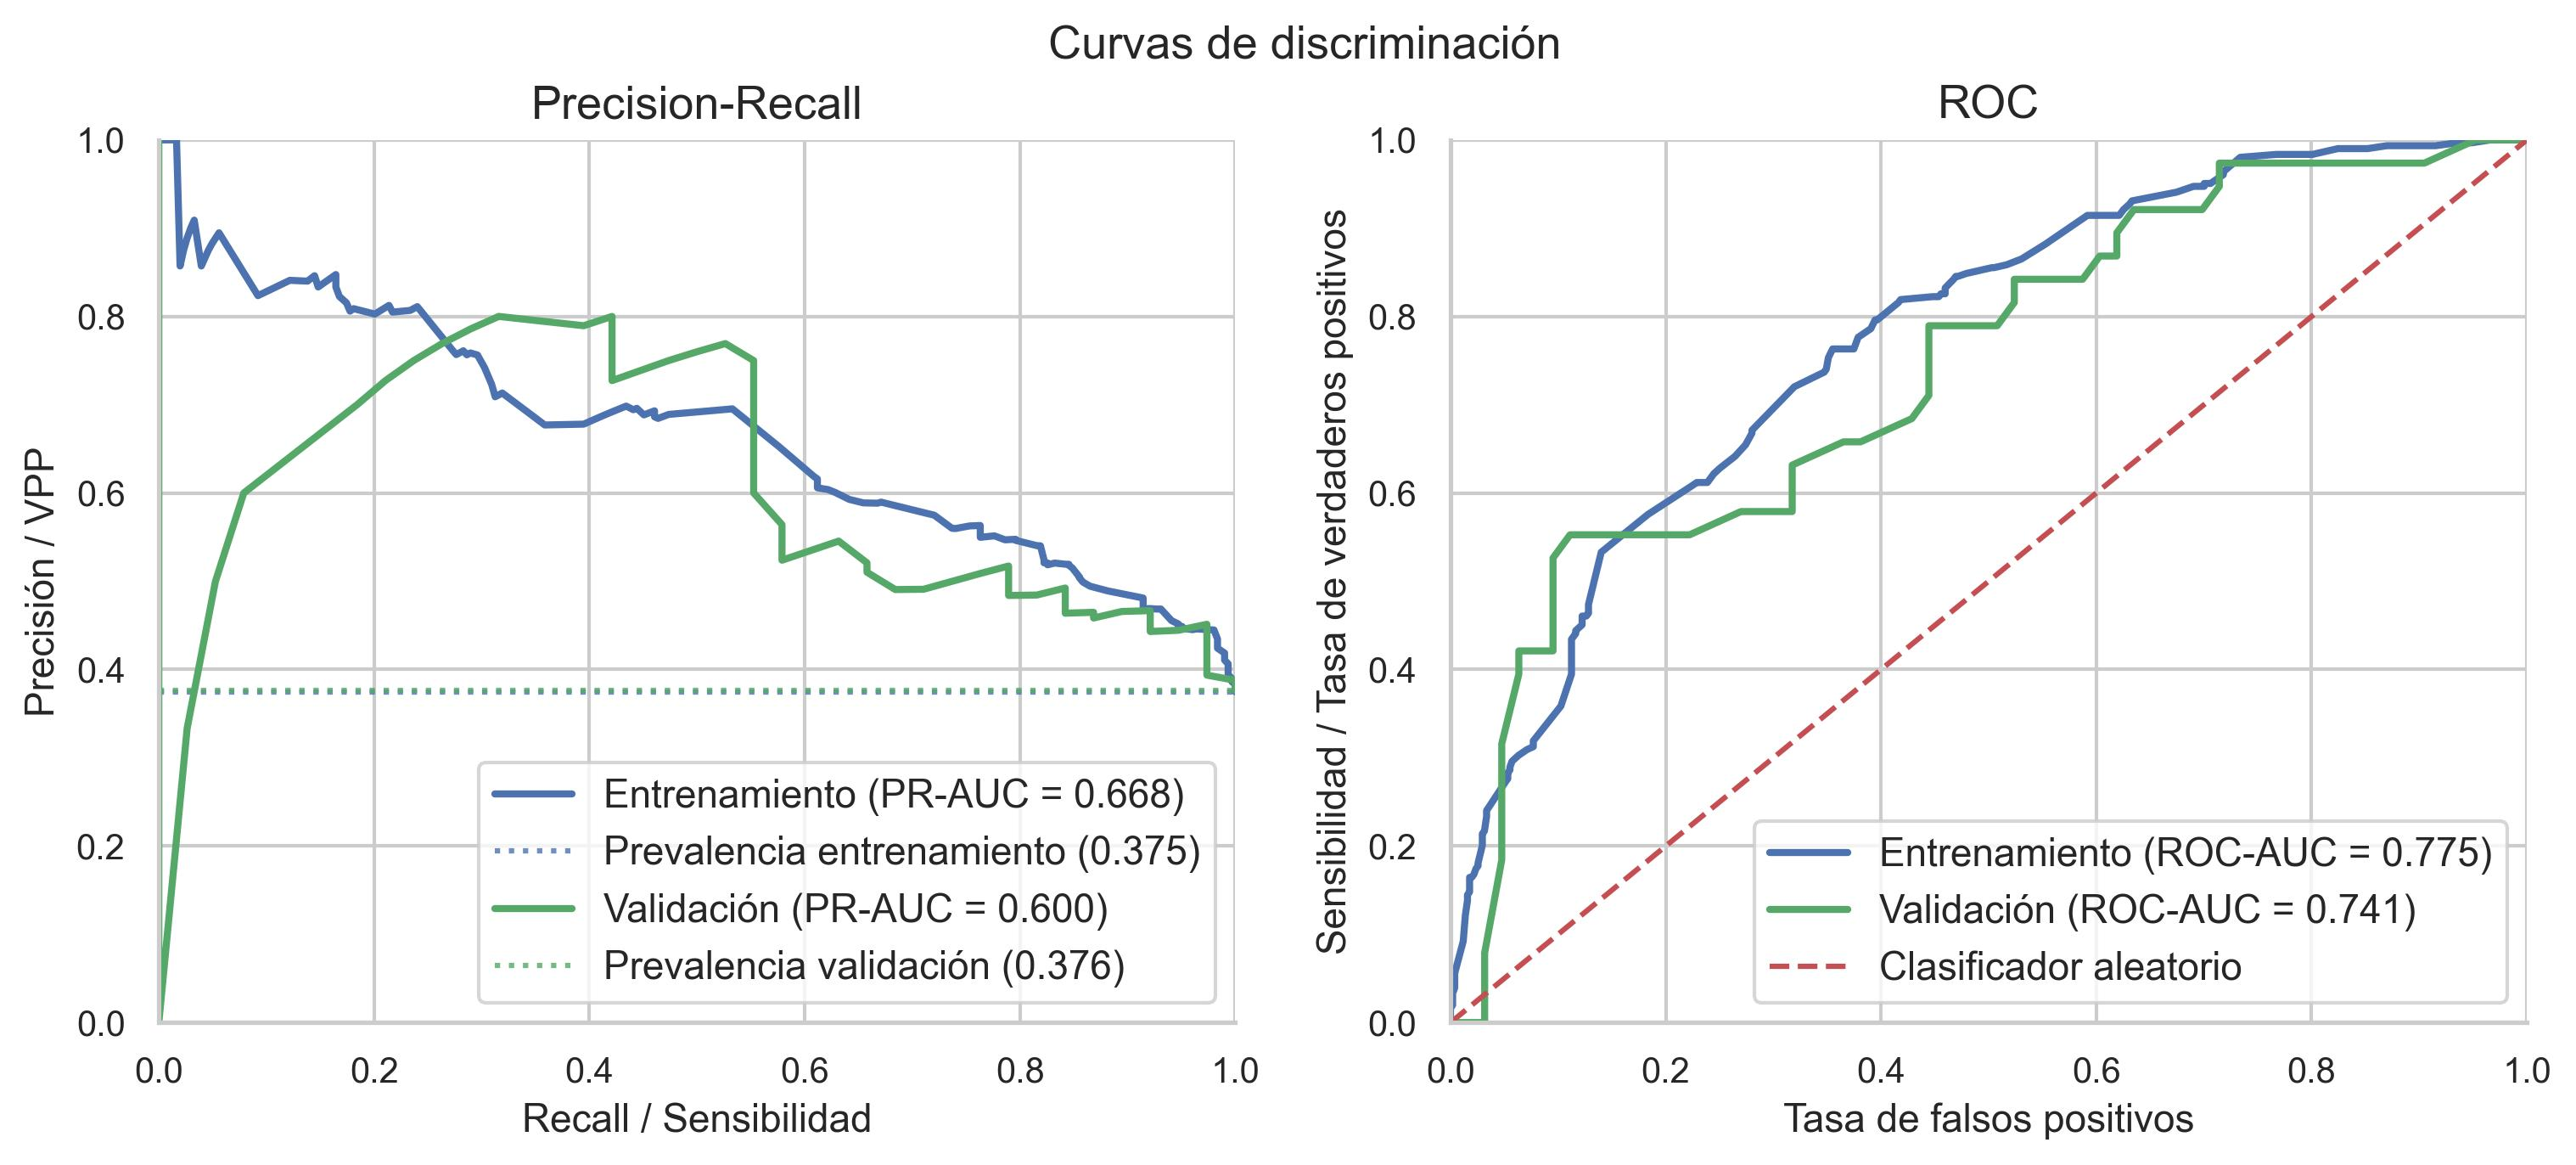

### Clinical Summary

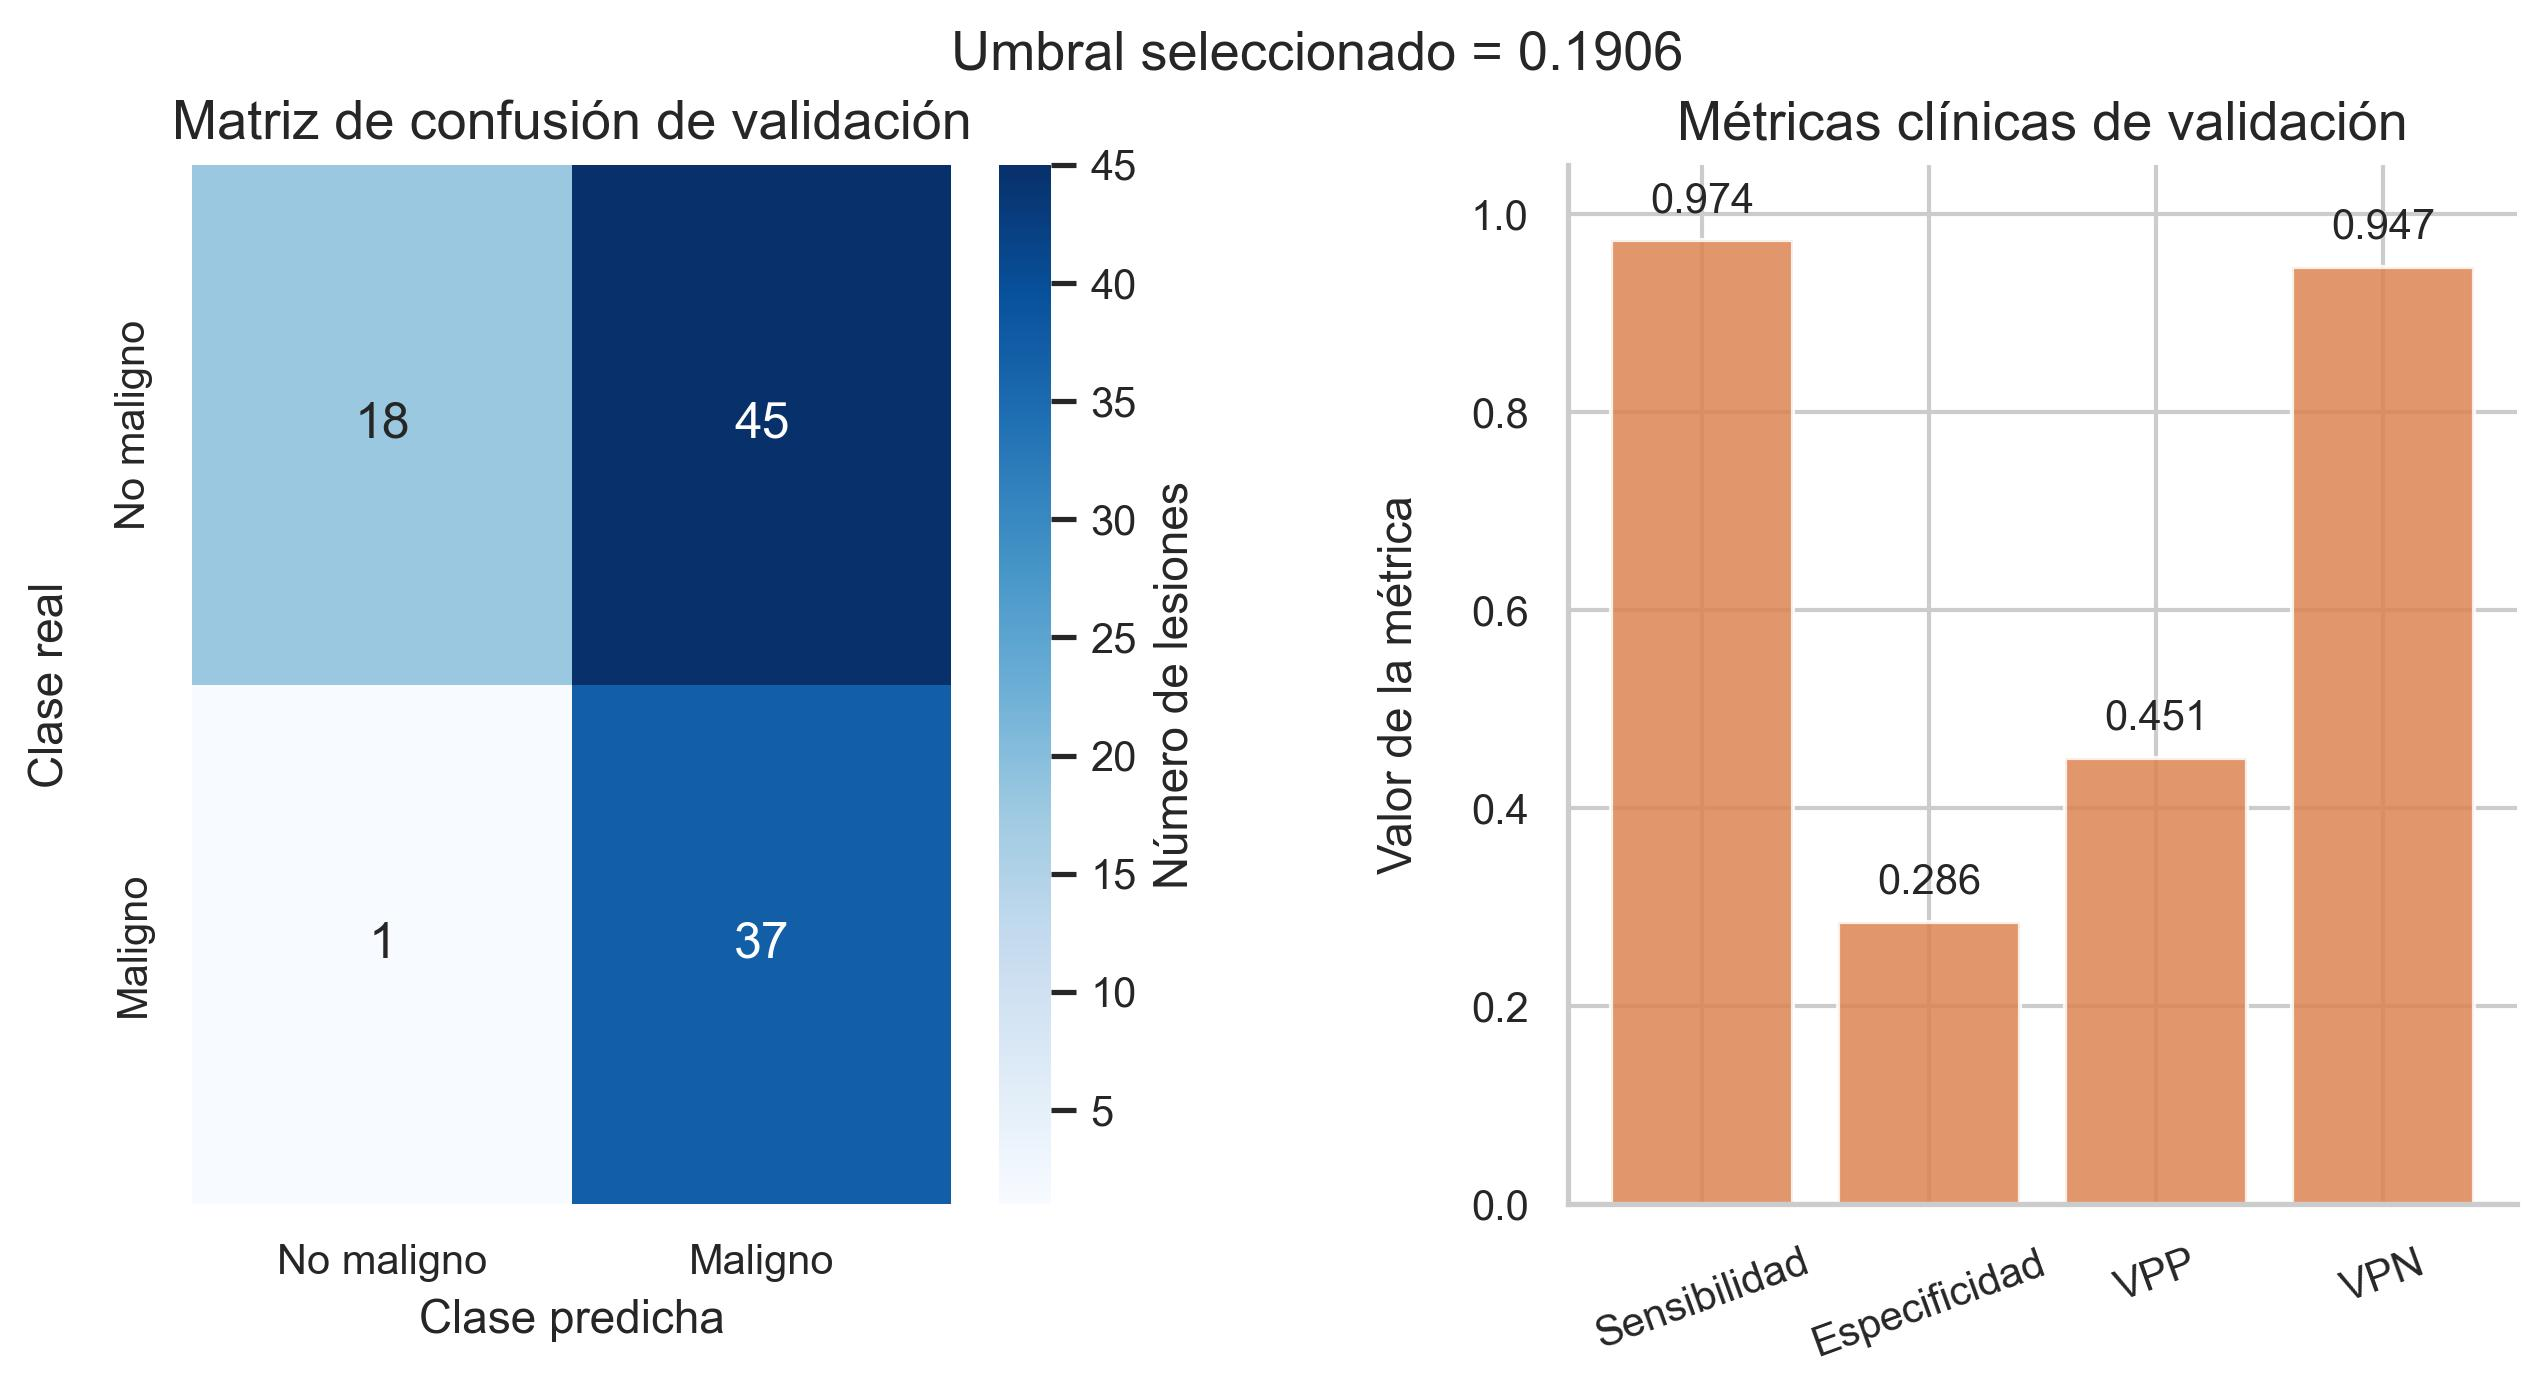

In [59]:
from IPython.display import Image, Markdown, display

for figure_name, figure_path in results["figure_paths"].items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
    display(Image(filename=str(figure_path)))